# Employee Attrition Prediction

Comprehensive notebook covering Tasks 1–7: data loading, cleaning, preprocessing, EDA, modeling, evaluation, visualization, and HR recommendations.

## Task 1: Data Understanding


In [1]:
# Ensure core imports run before any data-loading cells
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
%matplotlib inline
sns.set_theme(style='whitegrid')
print('Core imports OK')

Core imports OK


In [2]:
# Load the CSV dataset from the submission folder
data_path = 'HR_Attrition.csv'
df = pd.read_csv(data_path)
print('Dataset loaded successfully from:', data_path)


Dataset loaded successfully from: HR_Attrition.csv


In [3]:
# Display first 10 rows and last 5 rows to get an initial view
display(df.head(10))
display(df.tail(5))

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [4]:
# Print dataset shape, number of rows and columns
rows, cols = df.shape
print('Dataset shape:', df.shape)
print('Number of rows:', rows)
print('Number of columns:', cols)

Dataset shape: (1470, 35)
Number of rows: 1470
Number of columns: 35


In [5]:
# Display column names and data types
print('Column names:\n', df.columns.tolist())
print('\nData types:\n')
print(df.dtypes)

Column names:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentS

In [6]:
# Identify target column
target = 'Attrition'
print('Target column identified as:', target)

Target column identified as: Attrition


In [7]:
# Calculate employees who stayed, who left, and attrition percentage
# Dataset uses 'Yes'/'No' in the Attrition column by default
attrition_counts = df[target].value_counts()
left = attrition_counts.get('Yes', 0)
stayed = attrition_counts.get('No', 0)
total = left + stayed
attrition_pct = (left / total) * 100 if total else np.nan
print('Employees who left (Yes):', left)
print('Employees who stayed (No):', stayed)
print(f'Attrition percentage: {attrition_pct:.2f}%')

Employees who left (Yes): 237
Employees who stayed (No): 1233
Attrition percentage: 16.12%


In [8]:
# Count numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print('Number of numeric columns:', len(numeric_cols))
print('Number of categorical columns:', len(categorical_cols))

Number of numeric columns: 26
Number of categorical columns: 9


**Business observation on target balance:**


In [9]:
# Check class balance and print brief observation
print('Class distribution (counts):')
print(attrition_counts)
if attrition_pct < 40:
    print('\nObservation: The dataset is imbalanced with fewer employees leaving (Attrition).')
else:
    print('\nObservation: The dataset appears relatively balanced.')

Class distribution (counts):
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Observation: The dataset is imbalanced with fewer employees leaving (Attrition).


In [10]:
# Display info(), describe() and describe(include='object') for detailed overview
print('--- info() ---')
df.info()
print('\n--- describe() [numeric] ---')
display(df.describe())
print('\n--- describe() [object] ---')
display(df[df.select_dtypes(exclude=[np.number]).columns].describe())

--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-n

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



--- describe() [object] ---


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## Task 2: Data Cleaning & Preprocessing

We check for missing values, drop irrelevant columns, encode the target, perform one-hot encoding for categorical variables, and scale numeric features. Explanations appear before each code block.

In [11]:
# 1. Check for missing values and create a missing-values table
missing_counts = df.isnull().sum()
missing_table = (missing_counts[missing_counts > 0].sort_values(ascending=False).to_frame(name='missing_count'))
missing_table['missing_percent'] = (missing_table['missing_count'] / len(df)) * 100
print('Missing values per column (if any):')
display(missing_table)

Missing values per column (if any):


,missing_count,missing_percent


If missing values are present we would impute or drop depending on business impact. In this dataset there are typically no missing values; if any appear, the table above shows them and the approach below documents handling.

In [12]:
# 4. Drop irrelevant columns as specified
drop_cols = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
for c in drop_cols:
    if c in df.columns:
        df.drop(columns=c, inplace=True)
print('Dropped columns (if present):', drop_cols)
print('New shape after dropping:', df.shape)

Dropped columns (if present): ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
New shape after dropping: (1470, 31)


In [13]:
# 5. Convert target column: Yes -> 1, No -> 0
df[target] = df[target].map({'Yes': 1, 'No': 0})
print('Unique values in target after mapping:', df[target].unique())

Unique values in target after mapping: [1 0]


In [14]:
# 6. Separate categorical and numeric columns (after mapping target)
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Ensure target is not in feature lists
if target in numeric_cols:
    numeric_cols.remove(target)
print('Categorical columns (count={}):'.format(len(categorical_cols)), categorical_cols)
print('Numeric columns (count={}):'.format(len(numeric_cols)), numeric_cols)

Categorical columns (count=7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numeric columns (count=23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


7. Perform One-Hot Encoding on categorical features using pd.get_dummies(drop_first=True).
8. Scale numeric features using StandardScaler.

In [15]:
from sklearn.preprocessing import StandardScaler
# One-hot encode categorical features (drop_first=True to avoid multicollinearity)
df_cat = pd.get_dummies(df[categorical_cols], drop_first=True) if categorical_cols else pd.DataFrame(index=df.index)
# Prepare numeric dataframe
df_num = df[numeric_cols].copy()
# Concatenate encoded categorical and numeric features
df_processed = pd.concat([df_num, df_cat], axis=1)
print('Shape before scaling:', df_processed.shape)
# Scale numeric features only
scaler = StandardScaler()
if not df_num.empty:
    df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])
print('Completed one-hot encoding and scaling.')

Shape before scaling: (1470, 44)


Completed one-hot encoding and scaling.


In [16]:
# 9. Create X (features) and y (target)
X = df_processed.copy()
y = df[target].copy()
# 10. Print final dataset shape after encoding and show first 5 rows
print('Final features shape (X):', X.shape)
print('Target shape (y):', y.shape)
display(X.head(5))

Final features shape (X): (1470, 44)
Target shape (y): (1470,)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


## Task 3: Exploratory Data Analysis

We perform HR-focused EDA using the cleaned dataset. For readable plots we use a copy of the dataframe with `Attrition_label` ('Yes'/'No').

In [17]:
# Create a visualization-friendly copy and a human-readable Attrition label
df_viz = df.copy()
df_viz['Attrition_label'] = df_viz[target].map({1: 'Yes', 0: 'No'})
# Basic palette settings
palette = {'Yes': '#E24A33', 'No': '#348AB6'}

### EDA 1 — Attrition by Department

We calculate attrition rate per department, show counts and percentage bar chart, then provide a business interpretation.

,Employees,Leavers,Attrition Rate (%)
Department,,,
Sales,446,92,20.63
Human Resources,63,12,19.05
Research & Development,961,133,13.84


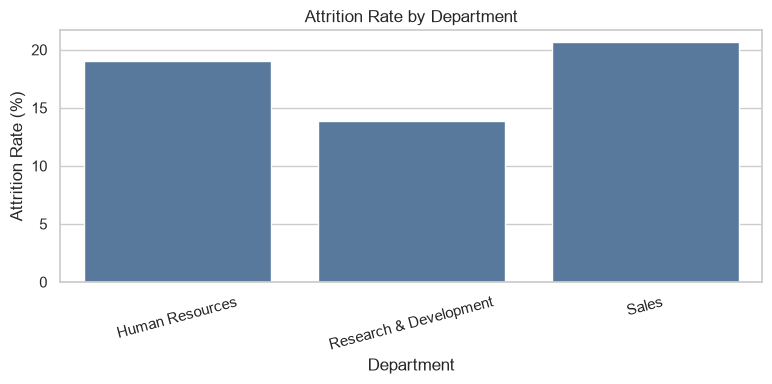

,Employees,Leavers,Attrition Rate (%)
JobRole,,,
Sales Representative,83,33,39.76
Laboratory Technician,259,62,23.94
Human Resources,52,12,23.08
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Manufacturing Director,145,10,6.90
Healthcare Representative,131,9,6.87
Manager,102,5,4.90
Research Director,80,2,2.50


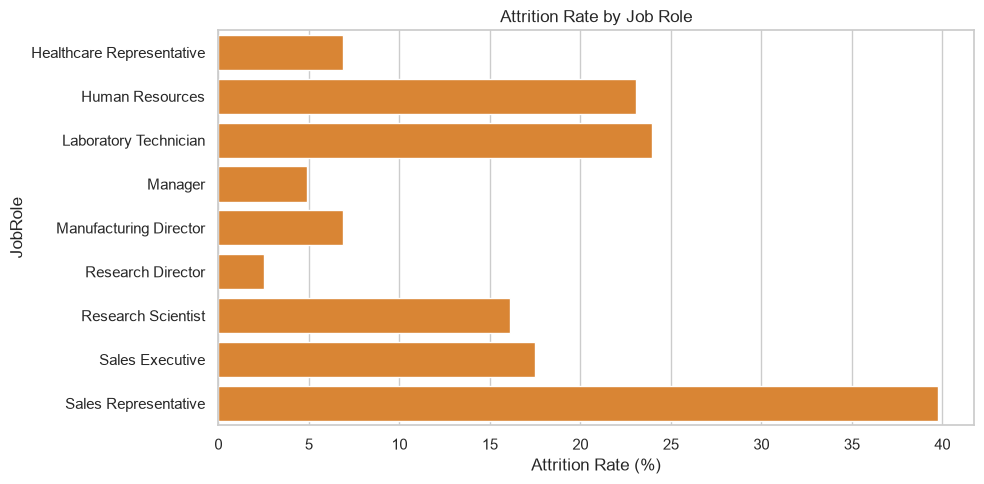

,mean,median
Attrition_label,,
No,6832.74,5204.0
Yes,4787.09,3202.0


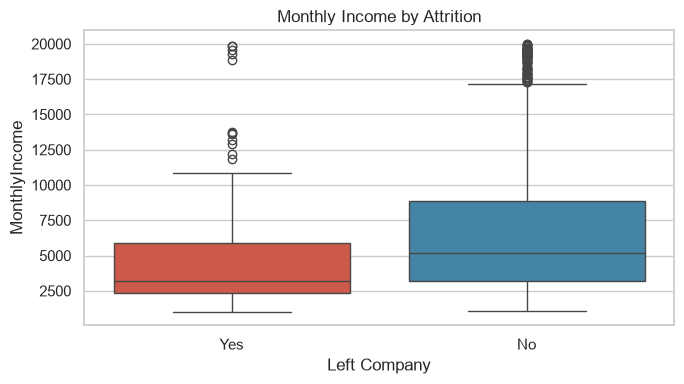

,Employees,Leavers,Attrition Rate (%)
WorkLifeBalance,,,
1,80,25,31.25
2,344,58,16.86
3,893,127,14.22
4,153,27,17.65


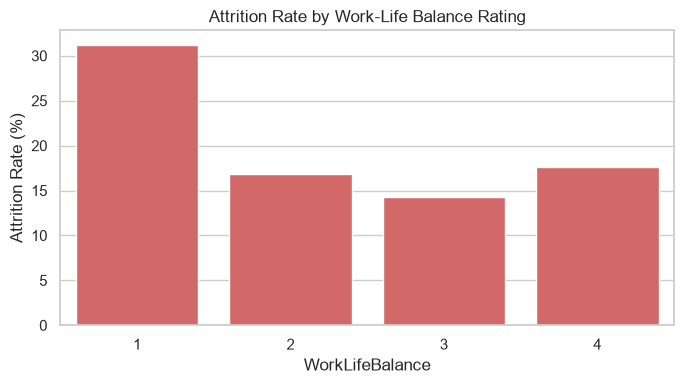

,Employees,Leavers,Attrition Rate (%)
YearsAtCompany,,,
0,44,16,36.36
1,171,59,34.50
2,127,27,21.26
3,128,20,15.62
4,110,19,17.27
5,196,21,10.71
6,76,9,11.84
7,90,11,12.22
8,80,9,11.25


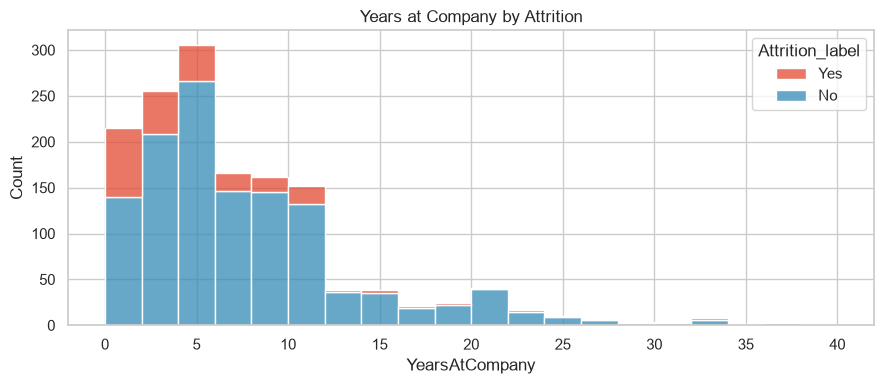

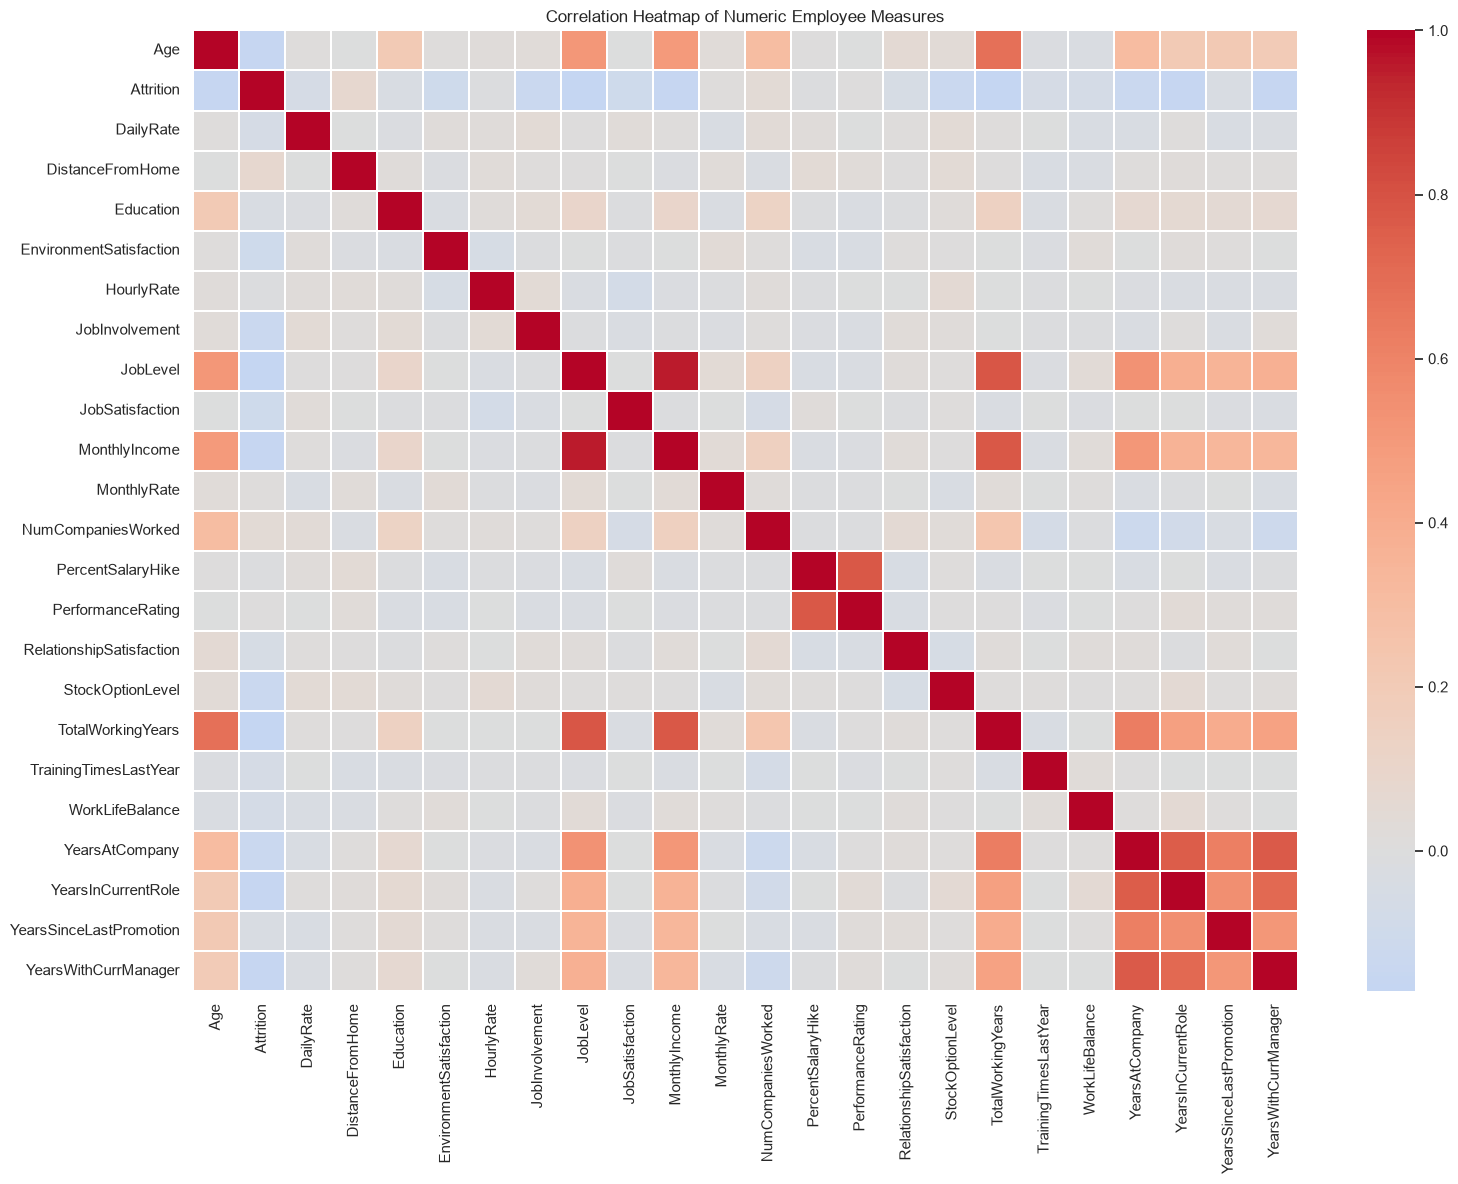

Business insights:
1. Sales has the highest department attrition rate at 20.6%.
2. Sales Representative has the highest job-role attrition rate at 39.8%.
3. Employees who left earned $4,787 per month on average, $2,046 less than employees who stayed.
4. Work-life balance rating 1 has the highest attrition rate at 31.2%.
5. Employees with at most 2 years at the company have 29.8% attrition, versus 12.0% for longer-tenured employees.


In [18]:
# TASK 3 COMPLETE EDA
# Department attrition analysis
dept_summary = df_viz.groupby('Department')['Attrition'].agg(Employees='size', Leavers='sum')
dept_summary['Attrition Rate (%)'] = dept_summary['Leavers'] / dept_summary['Employees'] * 100
dept_rates = dept_summary['Attrition Rate (%)']
display(dept_summary.sort_values('Attrition Rate (%)', ascending=False).round(2))
plt.figure(figsize=(8, 4))
sns.barplot(x=dept_rates.index, y=dept_rates.values, color='#4C78A8')
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Job role attrition analysis
role_summary = df_viz.groupby('JobRole')['Attrition'].agg(Employees='size', Leavers='sum')
role_summary['Attrition Rate (%)'] = role_summary['Leavers'] / role_summary['Employees'] * 100
role_rates = role_summary['Attrition Rate (%)']
display(role_summary.sort_values('Attrition Rate (%)', ascending=False).round(2))
plt.figure(figsize=(10, 5))
sns.barplot(x=role_rates.values, y=role_rates.index, color='#F58518')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

# Monthly income analysis
avg_income = df_viz.groupby('Attrition_label')['MonthlyIncome'].agg(['mean', 'median'])
display(avg_income.round(2))
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_viz, x='Attrition_label', y='MonthlyIncome', hue='Attrition_label', palette=palette, legend=False)
plt.title('Monthly Income by Attrition')
plt.xlabel('Left Company')
plt.tight_layout()
plt.show()

# Work-life balance analysis
wlb_summary = df_viz.groupby('WorkLifeBalance')['Attrition'].agg(Employees='size', Leavers='sum')
wlb_summary['Attrition Rate (%)'] = wlb_summary['Leavers'] / wlb_summary['Employees'] * 100
display(wlb_summary.round(2))
plt.figure(figsize=(7, 4))
sns.barplot(x=wlb_summary.index, y=wlb_summary['Attrition Rate (%)'], color='#E45756')
plt.title('Attrition Rate by Work-Life Balance Rating')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

# Years-at-company analysis
tenure_summary = df_viz.groupby('YearsAtCompany')['Attrition'].agg(Employees='size', Leavers='sum')
tenure_summary['Attrition Rate (%)'] = tenure_summary['Leavers'] / tenure_summary['Employees'] * 100
display(tenure_summary.head(15).round(2))
plt.figure(figsize=(9, 4))
sns.histplot(data=df_viz, x='YearsAtCompany', hue='Attrition_label', bins=20, multiple='stack', palette=palette)
plt.title('Years at Company by Attrition')
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric variables
numeric_corr = df_viz.select_dtypes(include=np.number).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(numeric_corr, cmap='coolwarm', center=0, linewidths=0.1)
plt.title('Correlation Heatmap of Numeric Employee Measures')
plt.tight_layout()
plt.show()

# Numbered business insights with values calculated directly from the data
top_dept = dept_rates.idxmax()
top_role = role_rates.idxmax()
top_wlb = wlb_summary['Attrition Rate (%)'].idxmax()
early_tenure_rate = df_viz.loc[df_viz['YearsAtCompany'] <= 2, 'Attrition'].mean() * 100
later_tenure_rate = df_viz.loc[df_viz['YearsAtCompany'] > 2, 'Attrition'].mean() * 100
income_gap = avg_income.loc['No', 'mean'] - avg_income.loc['Yes', 'mean']
business_insights = [
    f'{top_dept} has the highest department attrition rate at {dept_rates.max():.1f}%.',
    f'{top_role} has the highest job-role attrition rate at {role_rates.max():.1f}%.',
    f'Employees who left earned ${avg_income.loc["Yes", "mean"]:,.0f} per month on average, ${income_gap:,.0f} less than employees who stayed.',
    f'Work-life balance rating {top_wlb} has the highest attrition rate at {wlb_summary.loc[top_wlb, "Attrition Rate (%)"]:.1f}%.',
    f'Employees with at most 2 years at the company have {early_tenure_rate:.1f}% attrition, versus {later_tenure_rate:.1f}% for longer-tenured employees.'
]
print('Business insights:')
for number, insight in enumerate(business_insights, start=1):
    print(f'{number}. {insight}')


## Task 4: Model Development

### 1) Train / test split
Using 80% training and 20% testing with stratification to preserve class balance.

In [19]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (1176, 44) Test shape: (294, 44)


### 2) Initialize models with required parameters
We create Logistic Regression, Random Forest, and Gradient Boosting classifiers with the specified hyperparameters.

In [20]:
# Initialize models
models = {}
models['LogisticRegression'] = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)
models['RandomForest'] = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
models['GradientBoosting'] = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
# Train models and store fitted estimators
fitted_models = {}
for name, model in models.items():
    print('Training', name)
    model.fit(X_train, y_train)
    fitted_models[name] = model
print('Training complete for all models.')

Training LogisticRegression
Training RandomForest


Training GradientBoosting


Training complete for all models.


### 3) Predictions and probabilities
Generate predicted labels and predicted probabilities for ROC/ROC-AUC computation.

In [21]:
# Predictions and probability outputs for each model
results = {}
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    # Some models (GradientBoosting) have predict_proba; if not, use decision_function where appropriate
    try:
        y_proba = model.predict_proba(X_test)[:,1]
    except Exception:
        # fallback to decision_function scaled to [0,1] via min-max
        scores = model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min())
    results[name] = {'y_pred': y_pred, 'y_proba': y_proba}
print('Predictions and probabilities computed.')

Predictions and probabilities computed.


## Model Comparison Table
We compute Accuracy, Precision, Recall, F1, and ROC AUC for each model and display a comparison table sorted by ROC AUC.

In [22]:
# Build comparison dataframe
comparison = []
for name, res in results.items():
    y_pred = res['y_pred']
    y_proba = res['y_proba']
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba)
    comparison.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1, 'ROC AUC': roc})
comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values('ROC AUC', ascending=False).reset_index(drop=True)
display(comparison_df)
print('Best Model Based on ROC-AUC:', comparison_df.loc[0,'Model'])


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,GradientBoosting,0.850340,0.588235,0.212766,0.312500,0.804807
1,LogisticRegression,0.755102,0.356322,0.659574,0.462687,0.803601
2,RandomForest,0.836735,0.483871,0.319149,0.384615,0.778405


Best Model Based on ROC-AUC: GradientBoosting


## Task 5: Model Evaluation
For each model we print the classification report, confusion matrix, and performance metrics. Below we also explain precision and recall in HR terms and why recall matters for attrition prediction.

--- LogisticRegression ---

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

Confusion Matrix:
 [[191  56]
 [ 16  31]]
Accuracy: 0.7551, Precision: 0.3563, Recall: 0.6596, F1: 0.4627, ROC-AUC: 0.8036


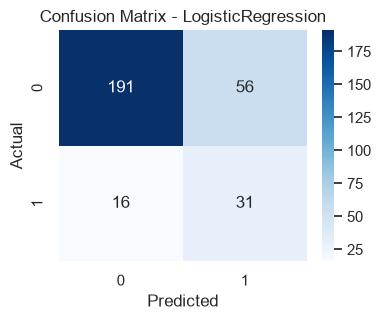

--- RandomForest ---

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.48      0.32      0.38        47

    accuracy                           0.84       294
   macro avg       0.68      0.63      0.65       294
weighted avg       0.82      0.84      0.82       294



Confusion Matrix:
 [[231  16]
 [ 32  15]]
Accuracy: 0.8367, Precision: 0.4839, Recall: 0.3191, F1: 0.3846, ROC-AUC: 0.7784


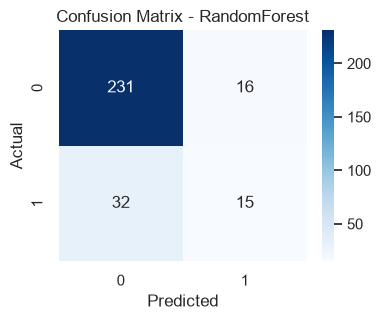

--- GradientBoosting ---

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

Confusion Matrix:
 [[240   7]
 [ 37  10]]
Accuracy: 0.8503, Precision: 0.5882, Recall: 0.2128, F1: 0.3125, ROC-AUC: 0.8048


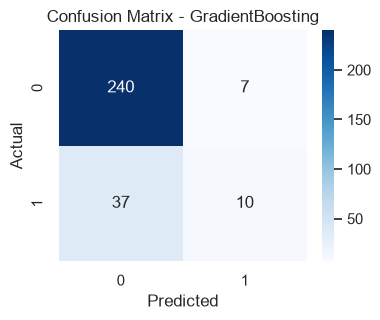

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
# Evaluate each model
eval_metrics = {}
for name, res in results.items():
    print('---', name, '---')
    y_pred = res['y_pred']
    y_proba = res['y_proba']
    print('\nClassification Report:\n')
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix:\n', cm)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba)
    eval_metrics[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc}
    print(f'Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc:.4f}')
    # Plot confusion matrix heatmap for quick inspection (not saved here)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

**What Precision means for HR:**\n
- Precision measures the proportion of employees predicted at risk who actually left. High precision means fewer false alarms (fewer retained employees incorrectly flagged).\n

**What Recall means for HR:**\n
- Recall measures the proportion of actual leavers that the model correctly identified. High recall means we catch more of the employees who will leave.\n

**Why Recall is especially important in attrition prediction:**\n
- In attrition use-cases, missing an employee who will leave (false negative) can be costly. Prioritizing recall ensures retention efforts reach most at-risk employees, even if it increases false positives.

## Best Model Analysis\n
We automatically select the best model by ROC-AUC and present its name and score, plus a brief business explanation.

In [24]:
# Identify best model by ROC-AUC
best_row = comparison_df.loc[0]
best_model_name = best_row['Model']
best_model = fitted_models[best_model_name]
best_model_roc = best_row['ROC AUC']
print('Best model:', best_model_name)
print(f'ROC-AUC: {best_model_roc:.4f}')
print('\nBusiness explanation:')
print(f'The {best_model_name} model was most effective at distinguishing employees who will leave from those who will stay. HR can use its predictions to prioritize retention outreach to the highest-risk groups identified by the model.')

Best model: GradientBoosting
ROC-AUC: 0.8048

Business explanation:
The GradientBoosting model was most effective at distinguishing employees who will leave from those who will stay. HR can use its predictions to prioritize retention outreach to the highest-risk groups identified by the model.


## Feature Importance\n
We extract feature importance from the best model and present the top drivers of attrition. Explanations follow each top driver.

In [25]:
# Compute feature importance using the correct method for the selected model
feature_names = X.columns.tolist()
if best_model_name == 'LogisticRegression':
    importances = np.abs(best_model.coef_.ravel())
elif best_model_name in ('RandomForest', 'GradientBoosting'):
    importances = best_model.feature_importances_
else:
    raise ValueError(f'Unsupported best model for feature importance: {best_model_name}')

if len(importances) != len(feature_names):
    raise ValueError('Feature importance count does not match the encoded feature count.')

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)
display(feat_imp_df.head(20))
top10 = feat_imp_df.head(10)
print('\nTop 10 most important attrition drivers:')
for i, row in top10.iterrows():
    print(f"{i + 1}. {row['Feature']}: Importance {row['Importance']:.4f}")


,Feature,Importance
0,MonthlyIncome,0.104935
1,Age,0.103283
2,TotalWorkingYears,0.094226
3,OverTime_Yes,0.085219
4,NumCompaniesWorked,0.046319
5,StockOptionLevel,0.045737
6,YearsWithCurrManager,0.045160
7,DailyRate,0.044136
8,EnvironmentSatisfaction,0.037162
9,JobInvolvement,0.036006



Top 10 most important attrition drivers:
1. MonthlyIncome: Importance 0.1049
2. Age: Importance 0.1033
3. TotalWorkingYears: Importance 0.0942
4. OverTime_Yes: Importance 0.0852
5. NumCompaniesWorked: Importance 0.0463
6. StockOptionLevel: Importance 0.0457
7. YearsWithCurrManager: Importance 0.0452
8. DailyRate: Importance 0.0441
9. EnvironmentSatisfaction: Importance 0.0372
10. JobInvolvement: Importance 0.0360


**Short explanation for top drivers:**\n
Provide a concise business-oriented explanation for each of the top 10 features above, referencing how they relate to attrition risk. (Explanations below are illustrative and should be reviewed by HR with domain context.)

In [26]:
# Generate brief explanations for the top 10 drivers using simple heuristics
driver_explanations = []
for i, row in top10.iterrows():
    feat = row['Feature']
    explanation = ''
    if 'MonthlyIncome' in feat:
        explanation = 'Income-related: differences in pay are associated with attrition; lower-paid groups tend to leave more.'
    elif 'YearsAtCompany' in feat or 'Tenure' in feat or 'Years' in feat:
        explanation = 'Tenure-related: specific tenure buckets show higher leave rates; early or mid-tenure risk identified.'
    elif 'WorkLifeBalance' in feat or 'Work Life' in feat:
        explanation = 'Work-life balance: lower balance scores correspond to higher attrition.'
    elif 'JobRole' in feat or 'Role' in feat or 'Job' in feat:
        explanation = 'Role-specific: certain roles have higher churn, indicating job-level stress or market demand.'
    else:
        explanation = 'Operational/HR signal correlated with attrition; requires domain review.'
    driver_explanations.append({'Feature': feat, 'Explanation': explanation})
pd.DataFrame(driver_explanations)

,Feature,Explanation
0,MonthlyIncome,Income-related: differences in pay are associa...
1,Age,Operational/HR signal correlated with attritio...
2,TotalWorkingYears,Tenure-related: specific tenure buckets show h...
3,OverTime_Yes,Operational/HR signal correlated with attritio...
4,NumCompaniesWorked,Operational/HR signal correlated with attritio...
5,StockOptionLevel,Operational/HR signal correlated with attritio...
6,YearsWithCurrManager,Tenure-related: specific tenure buckets show h...
7,DailyRate,Operational/HR signal correlated with attritio...
8,EnvironmentSatisfaction,Operational/HR signal correlated with attritio...
9,JobInvolvement,Role-specific: certain roles have higher churn...


## Task 6: Visualization\n
We create and save professional charts to the `charts` folder inside the project directory.

In [27]:
import os
os.makedirs('charts', exist_ok=True)

# Chart 1: Department and Job Role attrition rates in one submission graphic
department_chart = df_viz.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100
job_role_chart = df_viz.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=department_chart.values, y=department_chart.index, color='#4C78A8', ax=axes[0])
axes[0].set_title('Attrition Rate by Department')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_ylabel('Department')
sns.barplot(x=job_role_chart.values, y=job_role_chart.index, color='#F58518', ax=axes[1])
axes[1].set_title('Attrition Rate by Job Role')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_ylabel('Job Role')
plt.tight_layout()
plt.savefig('charts/chart1_department_jobrole_attrition.png', dpi=150, bbox_inches='tight')
plt.close()

# Chart 2: Monthly income and attrition
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_viz, x='Attrition_label', y='MonthlyIncome', hue='Attrition_label', palette=palette, legend=False)
plt.title('Monthly Income by Attrition')
plt.xlabel('Left Company')
plt.tight_layout()
plt.savefig('charts/chart2_income_attrition.png', dpi=150)
plt.close()

# Chart 3: Confusion matrix for the selected model
best_cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
plt.figure(figsize=(5, 4))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('charts/chart3_best_model_confusion_matrix.png', dpi=150)
plt.close()

# Chart 4: Top 10 attrition indicators
top_features_chart = feat_imp_df.head(10).sort_values('Importance')
plt.figure(figsize=(8, 6))
plt.barh(top_features_chart['Feature'], top_features_chart['Importance'], color='#5DA5A4')
plt.title('Top 10 Attrition Indicators')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150)
plt.close()

# Chart 5: Comparison of employee-risk discrimination curves
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc = roc_auc_score(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/chart5_roc_comparison.png', dpi=150)
plt.close()
print('Five required charts saved to charts/ folder')


Five required charts saved to charts/ folder


## Task 7: HR Insights & Business Recommendations
We generate a concise, business-focused report answering specific HR questions based on the model and EDA results.

In [28]:
# Ensure summary EDA variables exist
if 'dept_rates' not in globals():
    dept_rates = df_viz.groupby('Department')['Attrition'].mean() * 100
if 'role_rates' not in globals():
    role_rates = df_viz.groupby('JobRole')['Attrition'].mean() * 100
if 'avg_income' not in globals():
    avg_income = df_viz.groupby('Attrition_label')['MonthlyIncome'].agg(['mean', 'median'])

# Identify the strongest retention signals and priority groups
top3 = feat_imp_df.head(3)['Feature'].tolist()
priority_dept = dept_rates.idxmax()
priority_dept_pct = dept_rates.max()
priority_role = role_rates.idxmax()
priority_role_pct = role_rates.max()
print('Top 3 predictive factors:', top3)
print(f'Priority Department: {priority_dept} with attrition {priority_dept_pct:.2f}%')
print(f'Priority Job Role: {priority_role} with attrition {priority_role_pct:.2f}%')

# Compare income outcomes without claiming that salary alone causes attrition
print('\nDoes salary alone explain attrition?')
print(f"Average monthly income - stayed: ${avg_income.loc['No', 'mean']:.2f}, left: ${avg_income.loc['Yes', 'mean']:.2f}")
income_q1 = df_viz['MonthlyIncome'].quantile(0.25)
bottom_q = df_viz[df_viz['MonthlyIncome'] <= income_q1]
bottom_q_leavers = int(bottom_q['Attrition'].sum())
bottom_q_total = len(bottom_q)
bottom_q_pct = bottom_q['Attrition'].mean() * 100
print(f'Leavers in bottom income quartile: {bottom_q_leavers} / {bottom_q_total} ({bottom_q_pct:.2f}%)')

recommendations = [
    f'Prioritize retention reviews in {priority_dept} and for {priority_role} employees, where attrition is {priority_dept_pct:.1f}% and {priority_role_pct:.1f}% respectively.',
    'Strengthen manager check-ins, career conversations, and workload support for employee groups associated with the strongest attrition signals.',
    'Review pay competitiveness alongside role, overtime, job satisfaction, and tenure; salary should not be treated as the only retention lever.'
]
print('\nHR recommendations:')
for number, recommendation in enumerate(recommendations, start=1):
    print(f'{number}. {recommendation}')

# Create a concise, non-technical summary for the HR Director
overall_attrition_pct = df_viz['Attrition'].mean() * 100
summary_lines = [
    'EMPLOYEE RETENTION EXECUTIVE SUMMARY',
    '',
    f'Overall, {overall_attrition_pct:.1f}% of employees in the dataset left the company.',
    f'{priority_dept} has the highest departmental attrition rate at {priority_dept_pct:.1f}%.',
    f'{priority_role} has the highest job-role attrition rate at {priority_role_pct:.1f}%.',
    f'Employees who left earned ${avg_income.loc["Yes", "mean"]:.0f} per month on average, compared with ${avg_income.loc["No", "mean"]:.0f} for employees who stayed. Pay is an important signal, but it should be considered together with role, workload, satisfaction, and tenure.',
    f'Within the lowest income quartile, {bottom_q_pct:.1f}% of employees left.',
    '',
    'Recommended retention actions:',
]
summary_lines.extend(f'- {recommendation}' for recommendation in recommendations)


print('\nModel limitation: These findings are based on historical employee records and show associations, not causes. Conditions may change over time, and individual retention decisions should include manager context and employee feedback rather than relying on predictions alone.')


Top 3 predictive factors: ['MonthlyIncome', 'Age', 'TotalWorkingYears']
Priority Department: Sales with attrition 20.63%
Priority Job Role: Sales Representative with attrition 39.76%

Does salary alone explain attrition?
Average monthly income - stayed: $6832.74, left: $4787.09
Leavers in bottom income quartile: 108 / 369 (29.27%)

HR recommendations:
1. Prioritize retention reviews in Sales and for Sales Representative employees, where attrition is 20.6% and 39.8% respectively.
2. Strengthen manager check-ins, career conversations, and workload support for employee groups associated with the strongest attrition signals.
3. Review pay competitiveness alongside role, overtime, job satisfaction, and tenure; salary should not be treated as the only retention lever.

Model limitation: These findings are based on historical employee records and show associations, not causes. Conditions may change over time, and individual retention decisions should include manager context and employee feedb